# Fase 4: Tablero Interpretativo y Recomendaciones

**Project Terra** — Tablero visual interactivo que consolida los perfiles de cada clúster y sirve como base de un sistema de recomendación preliminar de cultivos según condiciones ambientales.

> Requiere que `03_clustering.ipynb` y `04_cluster_profiling.ipynb` se hayan ejecutado previamente para generar `data/processed/sensor_Crop_Dataset_clustered.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances_argmin_min

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Carga de Datos

In [2]:
clustered_path = "../data/processed/sensor_Crop_Dataset_clustered.csv"
df = pd.read_csv(clustered_path)

cluster_col = 'cluster_kmeans'
target = 'Crop'
feature_cols = [c for c in df.select_dtypes(include=np.number).columns if not c.startswith('cluster')]

# Nombres legibles de las columnas, para usar en títulos y ejes de los gráficos
nombres_legibles = {
    'Nitrogen': 'Nitrógeno',
    'Phosphorus': 'Fósforo',
    'Potassium': 'Potasio',
    'Temperature': 'Temperatura',
    'Humidity': 'Humedad',
    'pH_Value': 'Valor del pH',
    'Rainfall': 'Precipitación',
}

print(f"Dimensiones: {df.shape}")
df.head()

Dimensiones: (20000, 10)


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop,cluster_kmeans,cluster_hierarchical
0,-0.194526,0.263243,1.267102,-1.014884,0.398209,-1.613560,0.835917,Wheat,2,0
1,0.719418,0.920005,-0.888844,-0.556909,1.706133,-1.500767,-1.061136,Tomato,0,3
2,1.276206,0.802154,-1.034668,0.582042,0.822224,0.060466,-1.162575,Sugarcane,0,2
3,-1.482386,1.627335,-1.572150,-1.301155,-0.278378,-0.172904,-1.636999,Sugarcane,2,3
4,-1.322013,1.699590,-0.628804,-1.063698,-0.678517,1.533371,0.766203,Maize,1,0


## 2. Visualización de Clústeres
Como las 7 variables están estandarizadas y prácticamente no están correlacionadas entre sí (ver EDA), el PCA no logra concentrar la varianza en pocos componentes (PC1, PC2 y PC3 explican ~14.6%, 14.5% y 14.3% cada uno) y su proyección 2D no separa visualmente los clústeres. Por eso, junto al PCA, graficamos también `Phosphorus` vs. `pH_Value` — dos de las variables que realmente definen la partición de K-Means (ver `04_cluster_profiling.ipynb`) — donde los 4 clústeres sí se distinguen con claridad.

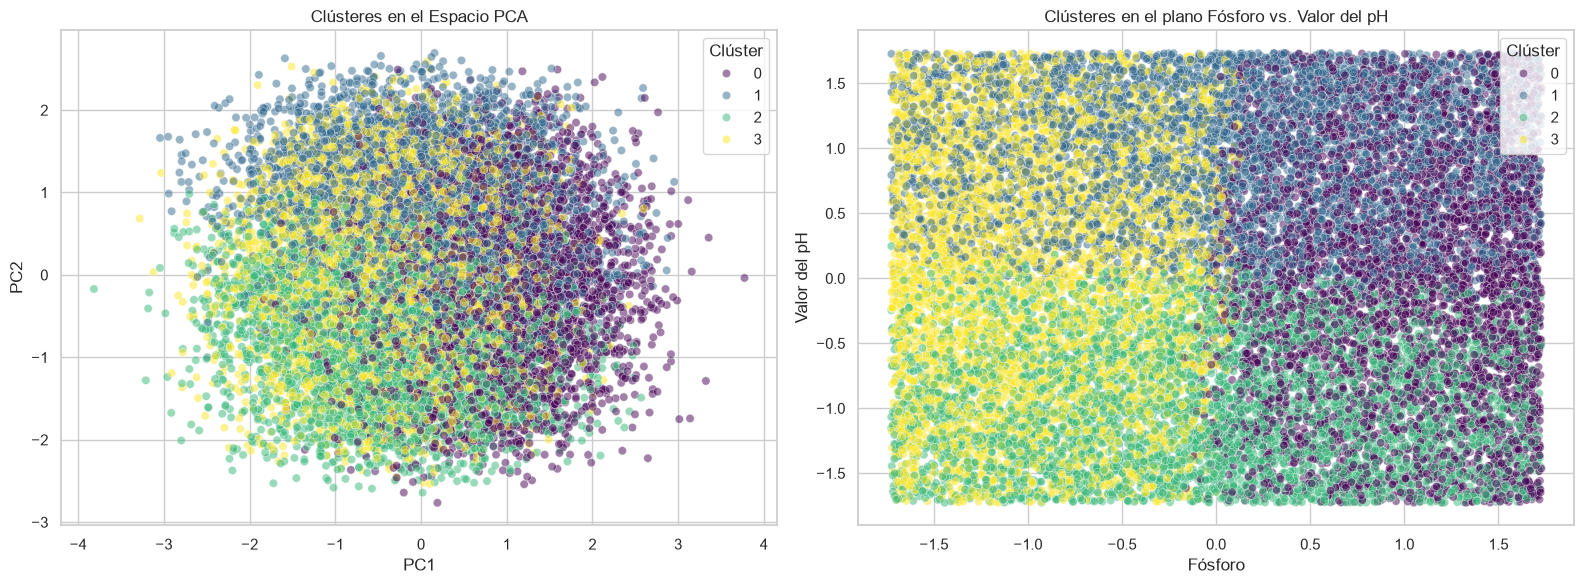

In [3]:
pca = PCA(n_components=2)
components = pca.fit_transform(df[feature_cols])

df_plot = df.copy()
df_plot['PC1'] = components[:, 0]
df_plot['PC2'] = components[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue=cluster_col, palette='viridis', alpha=0.5, ax=axes[0])
axes[0].set_title('Clústeres en el Espacio PCA')
axes[0].legend(title='Clúster')

sns.scatterplot(data=df_plot, x='Phosphorus', y='pH_Value', hue=cluster_col, palette='viridis', alpha=0.5, ax=axes[1])
axes[1].set_title('Clústeres en el plano Fósforo vs. Valor del pH')
axes[1].set_xlabel('Fósforo')
axes[1].set_ylabel('Valor del pH')
axes[1].legend(title='Clúster')

plt.tight_layout()
plt.show()

## 3. Radar — Firma Ambiental por Clúster

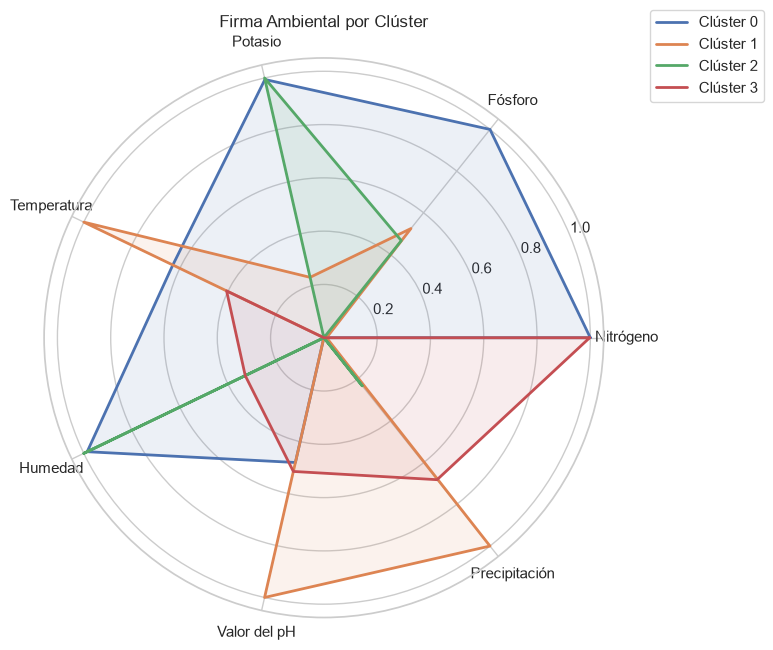

In [4]:
cluster_means = df.groupby(cluster_col)[feature_cols].mean()
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

categories = [nombres_legibles[c] for c in feature_cols]
n_vars = len(categories)
angles = [n / float(n_vars) * 2 * pi for n in range(n_vars)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for cluster_id, row in cluster_means_norm.iterrows():
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=f'Clúster {cluster_id}')
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_title('Firma Ambiental por Clúster')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

## 4. Distribución de Cultivos por Clúster

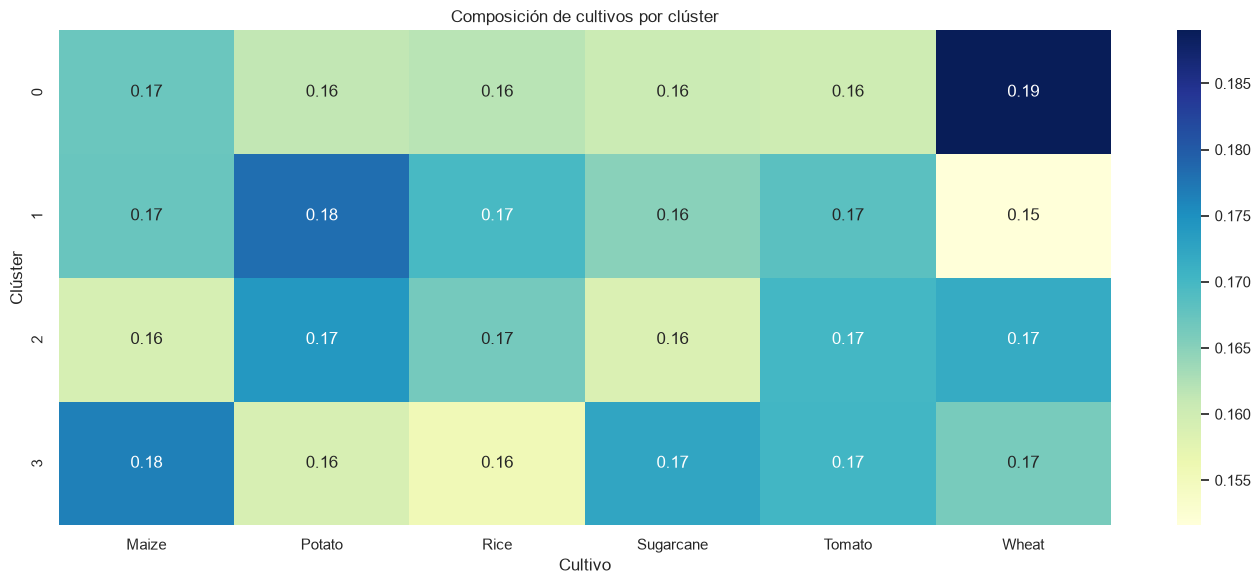

In [5]:
crosstab = pd.crosstab(df[cluster_col], df[target])
crosstab_share = crosstab.div(crosstab.sum(axis=1), axis=0)

plt.figure(figsize=(14, 6))
sns.heatmap(crosstab_share, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Composición de cultivos por clúster')
plt.xlabel('Cultivo')
plt.ylabel('Clúster')
plt.tight_layout()
plt.show()

## 5. Tabla Resumen de Perfiles

In [6]:
summary = df.groupby(cluster_col)[feature_cols].mean().round(2)
summary['n_registros'] = df[cluster_col].value_counts().sort_index()
summary['cultivo_dominante'] = crosstab.idxmax(axis=1)
summary

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,n_registros,cultivo_dominante
cluster_kmeans,,,,,,,,,
0,0.82,0.97,0.05,0.01,0.05,-0.04,-0.03,4947,Wheat
1,-0.81,0.06,-0.03,0.04,-0.06,0.95,0.03,5020,Potato
2,-0.83,-0.05,0.05,-0.04,0.05,-0.95,-0.02,4964,Potato
3,0.81,-0.94,-0.06,-0.01,-0.03,0.03,0.01,5069,Maize


## 6. Sistema de Recomendación Preliminar
Dado un nuevo registro con variables de suelo/clima (ya estandarizadas con el `StandardScaler` de `02_preprocessing_pca.ipynb`), lo asignamos al clúster cuyo centroide esté más cerca y recomendamos su cultivo dominante.

In [7]:
centroids = df.groupby(cluster_col)[feature_cols].mean().values

def recomendar_cultivo(nuevo_registro):
    """Recibe un dict con las variables en feature_cols (ya escaladas) y devuelve
    el clúster más cercano y su cultivo dominante."""
    valores = np.array([[nuevo_registro[col] for col in feature_cols]])
    idx_cluster, _ = pairwise_distances_argmin_min(valores, centroids)
    cluster_asignado = idx_cluster[0]
    cultivo_recomendado = crosstab.loc[cluster_asignado].idxmax()
    return cluster_asignado, cultivo_recomendado

# Ejemplo de uso (valores ya estandarizados; 0.0 equivale a la media del dataset)
ejemplo = {col: 0.0 for col in feature_cols}
cluster_id, cultivo = recomendar_cultivo(ejemplo)
print(f"Clúster asignado: {cluster_id} | Cultivo recomendado: {cultivo}")

Clúster asignado: 3 | Cultivo recomendado: Maize


## 7. Conclusiones prácticas y estratégicas

- **Ecorregiones funcionales identificadas**: con K=4, K-Means separa las zonas principalmente por Fósforo y pH, con Nitrógeno como tercer eje (ver `04_cluster_profiling.ipynb`). El gráfico de `Phosphorus` vs. `pH_Value` de la sección 2 muestra los 4 clústeres claramente separados en cruz, aunque el PCA general no lo refleje (las 7 variables están casi descorrelacionadas, así que PCA no concentra la varianza en 2 componentes). Esto confirma que las 'ecorregiones' resultantes reflejan sobre todo el perfil de fertilización/pH del suelo, más que un perfil climático-edáfico integral.
- **Valor práctico**: la función `recomendar_cultivo()` asigna una zona nueva al centroide más cercano; por ejemplo, un registro con todas las variables en su valor promedio (0.0 tras estandarizar) se asigna al Clúster 3 y recomienda **Maize**.
- **Limitaciones**: dado el ARI ≈ 0 entre K-Means y el clustering jerárquico, la silueta baja (~0.1) y que el cultivo dominante por clúster apenas supera la proporción base del dataset (17-19%), el 'cultivo recomendado' por clúster debe tomarse como una aproximación preliminar y no como una regla agronómica validada. Variables no usadas en el clustering, como `Soil_Type` y `Variety`, podrían mejorar la coherencia.
- **Próximos pasos**: (a) repetir el clustering usando solo `Nitrogen`/`Phosphorus`/`pH_Value` (las variables que realmente separan los grupos) o, alternativamente, ponderar las variables para que `Potassium`/`Temperature`/`Humidity`/`Rainfall` pesen más; (b) incorporar `Soil_Type` y `Variety` como variables categóricas (one-hot) para enriquecer el perfil; (c) validar el sistema con datos de campo reales.